# Mesh

The mesh stage turns the VGGT-Omega depth maps and cameras in `pointcloud.zarr` into a surface.
It fuses every depth map into one voxel grid, extracts a triangle mesh, cleans it, and bakes the
keyframes onto it as a texture atlas. This page runs each step by hand on the shared scene, then
looks at the textured mesh the stage itself wrote.

In [ ]:
import numpy as np
import open3d as o3d
import pyvista as pv
from IPython.display import display

from collab_splats.geometry.transforms import invert_poses
from collab_splats.mesh import (
    clean_repair_mesh,
    compute_tsdf_voxel_size,
    create_tsdf_mesh,
    prepare_mesh,
)
from collab_splats.pointcloud import PointcloudResult
from collab_splats.pointcloud.utils import frame_depths
from collab_splats.preproc import frames
from collab_splats.semantics import sky_masks
from collab_splats.utils.image import open_image, resize_image

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "mesh")

## 1. TSDF fusion

A truncated signed distance function (TSDF) stores, in each voxel, the signed distance to the
nearest surface, averaged over every view that sees it. Marching cubes then extracts the zero
crossing as a mesh.

Two numbers control the grid. `voxel_size` is its resolution. `sdf_trunc` is how far in front of
and behind a surface a view still writes, and it is `sdf_trunc`, not `voxel_size`, that sets the
thinnest structure that survives. A surface thinner than the truncation band cancels out when
both of its sides are seen, and is fattened when only one side is.

The depth comes from the pointcloud zarr. `frame_depths` drops pixels below the
`conf_percentile` confidence on the model grid, then lifts the depth up to frame resolution.
Because the depth now lives on the frame grid, it pairs with the full-resolution `intrinsics`,
not the model-grid `model_intrinsics`.

In [ ]:
cfg = scene.config["mesh"]
out_dir = work_dir("mesh")

# Depth, cameras and frames in the zarr's own row order
pointcloud = PointcloudResult.load_zarr(
    scene.pointcloud_zarr, load_images=False, load_world_points=False
)
image_ids = [frames.frame_idx_from_path(p) for p in pointcloud.image_paths]
rgbs = frames.read_frames(scene.images_dir, image_ids)
depths = frame_depths(pointcloud, rgbs, conf_percentile=cfg["conf_percentile"])
c2w = invert_poses(pointcloud.extrinsics)

# Depth was predicted on the model grid, so its focal sets the voxel below
depth_fx = float(np.median(pointcloud.model_intrinsics[:, 0, 0]))

valid = np.count_nonzero(depths) / depths.size
print(f"depth {depths.shape}, {valid:.1%} of pixels kept")

Sky has no depth worth fusing. Left in, it fuses as a distant backdrop and seeds floaters.
`sky_masks` segments it per keyframe and caches the masks in the `cache_dir` it is given, here
inside this page's work directory; zeroing the masked depth removes it from fusion. The stage
does the same when `mesh.mask_sky` is on, which is the default.

In [3]:
# Zero the depth wherever the sky segmenter fires
sky = sky_masks(scene.images_dir, idxs=image_ids, cache_dir=out_dir / "sky")
depths = np.where(sky, 0.0, depths)
print(f"sky: {sky.mean():.1%} of pixels")

sky: 23.7% of pixels


In [ ]:
# Voxel from the scene's own depth: voxel_depth_px depth pixels at the reference depth
voxel_size = compute_tsdf_voxel_size(
    depths,
    c2w,
    pointcloud.intrinsics,
    depth_fx=depth_fx,
    depth_px=cfg["voxel_depth_px"],
    ref_percentile=cfg["voxel_ref_percentile"],
)

# Fuse into one grid; the band is sdf_trunc_mult voxels wide
sdf_trunc = cfg["sdf_trunc_mult"] * voxel_size
fused = create_tsdf_mesh(
    depths, rgbs, c2w, pointcloud.intrinsics, voxel_size=voxel_size, sdf_trunc=sdf_trunc
)
print(f"voxel {voxel_size:.4f}, sdf_trunc {sdf_trunc:.4f}")
print(f"fused: {len(fused.triangles):,} triangles")

## 2. Cleaning

The fused mesh carries floaters and small holes. `clean_repair_mesh` removes disconnected
fragments and fills holes. Its thresholds are fractions of the mesh's own extent, so one setting
works across scene sizes. With `use_convex_hull` it also trims the ragged outer edge and patches
the ground out to a rounded hull, which suits outdoor scenes dominated by ground. It returns two
meshes: the cleaned one, and the surface right after the floater cut, with no hull or hole fill.
The floater cut edits its input in place, so the page passes a copy and keeps the fused mesh to
compare.

`prepare_mesh` then fills the remaining small holes, decimates to at most `max_faces`, makes the
mesh manifold and smooths it. Its result is what the stage writes as `mesh.ply`. The floater-cut
surface is kept, because texturing uses it to test visibility.

In [ ]:
# Clean a copy; the floater-cut surface comes back as the texture occluder
cleaned, real = clean_repair_mesh(
    o3d.geometry.TriangleMesh(fused), use_convex_hull=cfg["use_convex_hull"]
)
prepared = prepare_mesh(
    cleaned,
    voxel_size=voxel_size,
    smooth_iterations=cfg["smooth_iterations"],
    max_faces=cfg["max_faces"],
)

print(f"fused    {len(fused.triangles):>10,} triangles")
print(f"cleaned  {len(cleaned.triangles):>10,} triangles")
print(f"prepared {len(prepared.triangles):>10,} triangles")

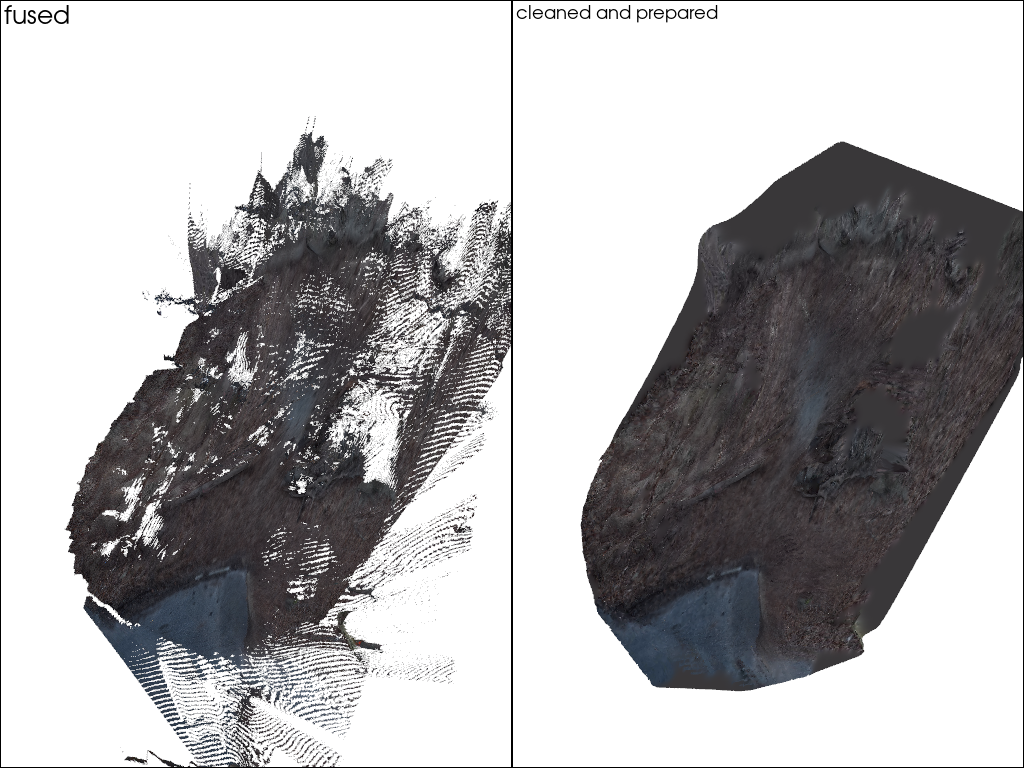

In [6]:
# Fused mesh on the left, prepared mesh on the right
fused_path = out_dir / "fused.ply"
prepared_path = out_dir / "prepared.ply"
o3d.io.write_triangle_mesh(str(fused_path), fused)
o3d.io.write_triangle_mesh(str(prepared_path), prepared)

pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_text("fused", font_size=10)
fused_pv = pv.read(str(fused_path))
pl.add_mesh(fused_pv, rgb=True, lighting=False)
pl.subplot(0, 1)
pl.add_text("cleaned and prepared", font_size=10)
prepared_pv = pv.read(str(prepared_path))
pl.add_mesh(prepared_pv, rgb=True, lighting=False)
pl.link_views()

# Unlit, so the panels show the fused colors; zoom in on the scene
pl.camera.zoom(1.8)
pl.show()

Look for floating specks and the ragged outer rim in the fused mesh; the prepared mesh should
have neither, and its small holes should be patched.

## 3. Texture

Vertex colors can only be as sharp as the vertices are dense. A texture atlas separates color
from geometry: the mesh is cut into charts, the charts are packed into one image, and each texel
is filled by projecting the keyframes onto the surface. With `mesh.texture: true` the stage
calls `create_texture_mesh` on the prepared mesh, and three choices shape the result.

- Occluder: visibility is tested against the floater-cut surface from `clean_repair_mesh`, with
  no hull or hole fill. A patch that hole filling invented can therefore never hide a real
  surface from a camera.
- Two bands: each frame splits into a blurred base and the detail left over. The base averages
  every view that sees a texel, so color does not jump where the sharpest view changes; the
  detail comes only from the views within 1.5x of the texel's sharpest, so the texture stays
  sharp.
- View charts: the charts are cut from the source images themselves. A face takes its color
  from a view only where it owns those pixels in that view's depth buffer. Faces no view fully
  sees get a flat patch along their mean normal. All charts pack into one 8192 px atlas.

The stage writes `mesh.obj`, `mesh.mtl` and `albedo.png` into `texture/` beside `mesh.ply`.

stage mesh.ply: 590,883 triangles


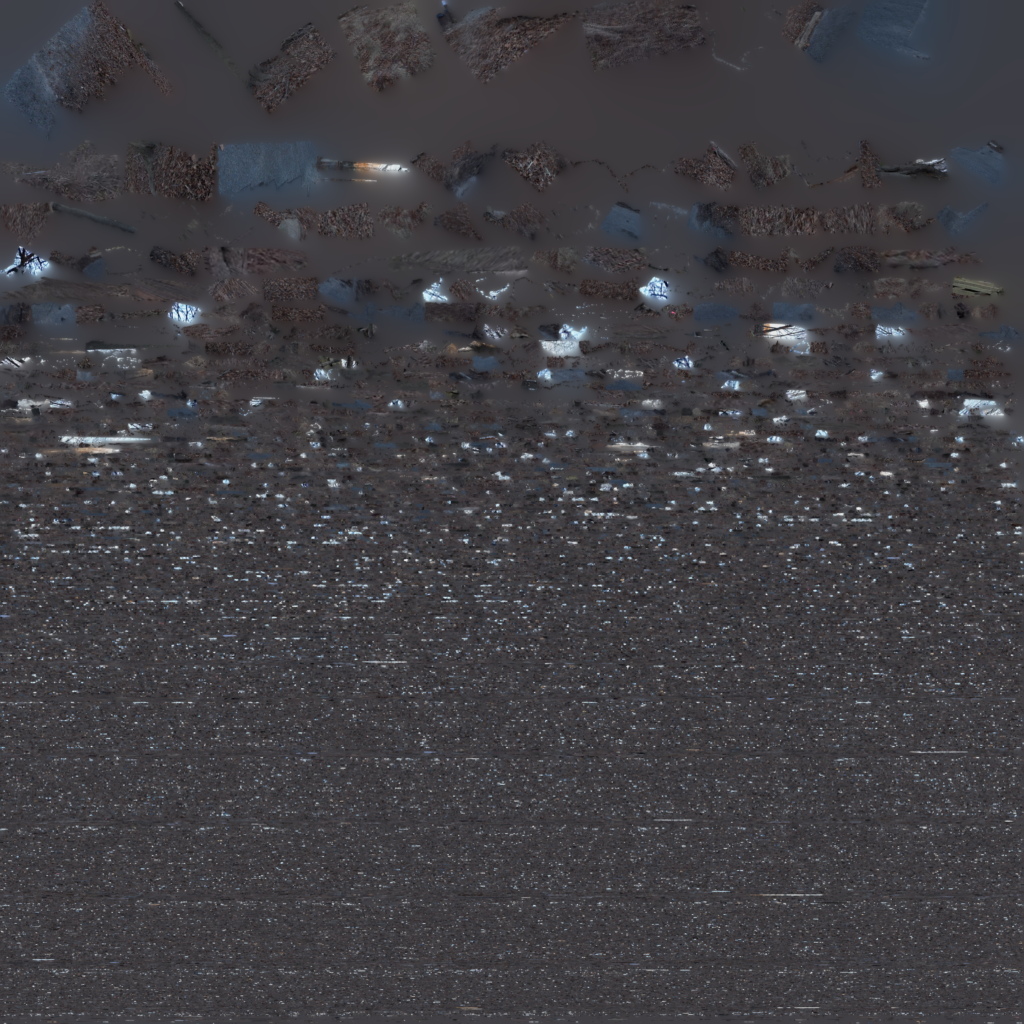

In [7]:
texture_dir = scene.backend_dir / "texture"

# The stage's own prepared mesh, the one the texture was baked onto
stage_mesh = o3d.io.read_triangle_mesh(str(scene.outputs["mesh"]))
print(f"stage mesh.ply: {len(stage_mesh.triangles):,} triangles")

# The 8192 px atlas, shown at 1024 px
atlas = open_image(texture_dir / "albedo.png")
preview = resize_image(atlas, 1024)
display(preview)

Each island is one view's chart. Texels that no camera saw are filled from their seen
neighbors, so those regions show no gaps but look smeared.

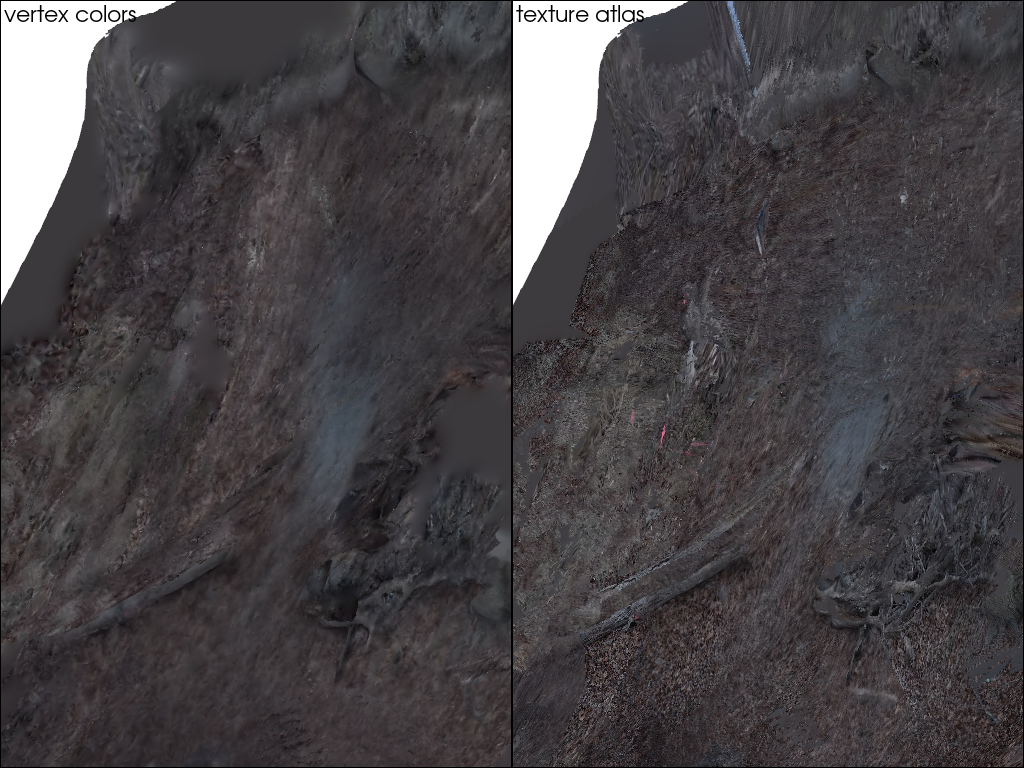

In [8]:
# The stage mesh with vertex colors, and the same mesh with its atlas
vertex_colored = pv.read(str(scene.outputs["mesh"]))
textured = pv.read(str(texture_dir / "mesh.obj"))
albedo = pv.read_texture(str(texture_dir / "albedo.png"))

# Unlit, linked views zoomed in on the middle of the scene
pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_text("vertex colors", font_size=10)
pl.add_mesh(vertex_colored, rgb=True, lighting=False)
pl.subplot(0, 1)
pl.add_text("texture atlas", font_size=10)
pl.add_mesh(textured, texture=albedo, lighting=False)
pl.link_views()
pl.camera.zoom(4)
pl.show()

Both panels are the same mesh. On the left, color is only as sharp as the vertices are dense;
on the right, the atlas carries detail between them.

The same bake runs outside a pipeline run as
`create_texture_mesh(prepared, real, out_dir, rgbs, c2w, K, voxel_size=voxel_size)`, with `K` at
image resolution. It needs CUDA.

## In a pipeline run

The `mesh` stage runs sections 1 to 3 in one call and writes `mesh.ply`, plus `texture/` when
`texture` is on. These are the mesh keys from `configs/base.yaml`, which the shared scene uses
unchanged:

```yaml
mesh:
  source: feedforward       # pointcloud.zarr depth
  voxel_depth_px: 4.0       # voxel edge in depth-pixel footprints
  voxel_ref_percentile: 50  # depth percentile the footprint is measured at
  sdf_trunc_mult: 4.0       # sdf_trunc = sdf_trunc_mult x voxel_size
  conf_percentile: 20
  mask_sky: true            # zero sky depth before fusion
  max_faces: 1500000        # face budget for mesh.ply
  smooth_iterations: 10
  texture: true             # UV atlas into texture/; CUDA only
  use_convex_hull: true
```